# Models: BE vs SC

Explore the two computational models on synthetic data.
No real data needed — this is a playground for understanding
what distinguishes Boundary Estimation from Stimulus Category.

**Key question:** Given the same stimuli, how do BE and SC animals
behave differently, and what signatures can we detect?


## Setup


In [1]:
%matplotlib inline

import sys, os
from pathlib import Path

_DEV_ROOT = Path(os.path.abspath(''))
_NOTEBOOK_DIR = _DEV_ROOT.parent
_PROJECT_ROOT = _NOTEBOOK_DIR.parent

if str(_NOTEBOOK_DIR) not in sys.path:
	sys.path.insert(0, str(_NOTEBOOK_DIR))
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

from shared_setup import *

from models.BE_core import BEModel, BEParams, BEState
from models.SC_core import SCModel, SCParams, SCState

from behav_utils.analysis.update_matrix import compute_update_matrix
from behav_utils.analysis.psychometry import fit_psychometric
from behav_utils.analysis.utils import cumulative_gaussian
from behav_utils.plotting.psychometric import plot_psychometric
from behav_utils.plotting.update_matrix import plot_um
from behav_utils.plotting.styles import COLOURS, PALETTE, apply_style

apply_style()

BE_COL = COLOURS.get('BE', PALETTE[0])
SC_COL = COLOURS.get('SC', PALETTE[1])


## 1. Model Parameters

BE has 4 parameters: sigma_percep, A_repulsion, eta_learning, eta_relax.
SC has 4 parameters: sigma_percep, A_repulsion, gamma, sigma_update.

sigma_percep and A_repulsion are shared (perception stage).
The strategy-specific parameters determine how the animal updates.


In [2]:
# Default parameter sets (typical values)
be_params = BEParams(sigma_percep=0.15, A_repulsion=0.10, eta_learning=0.30, eta_relax=0.15)
sc_params = SCParams(sigma_percep=0.15, A_repulsion=0.10, gamma=0.50, sigma_update=0.20)

print('BE parameters:')
for k, v in vars(be_params).items():
    if not k.startswith('_'):
        print(f'  {k}: {v}')

print('\nSC parameters:')
for k, v in vars(sc_params).items():
    if not k.startswith('_'):
        print(f'  {k}: {v}')


BE parameters:
  sigma_percep: 0.15
  A_repulsion: 0.1
  eta_learning: 0.3
  eta_relax: 0.15

SC parameters:
  sigma_percep: 0.15
  A_repulsion: 0.1
  gamma: 0.5
  sigma_update: 0.2


## 2. Simulate One Session

Run both models on the same stimulus sequence and compare choices.


In [3]:
# Generate a uniform stimulus sequence
rng = np.random.default_rng(42)
n_trials = 500
stimuli = rng.uniform(-1, 1, n_trials)
categories = (stimuli > 0).astype(int)
no_response = np.zeros(n_trials, dtype=bool)
not_blockstart = np.ones(n_trials, dtype=bool)
not_blockstart[0] = False

# Simulate both models
be_choices, be_boundaries, be_state, be_trace = BEModel.simulate_session(
    stimuli=stimuli, categories=categories,
    params=be_params, initial_state=BEState.initial_uniform(),
    rng=np.random.default_rng(42),
    no_response=no_response, not_blockstart=not_blockstart,
)

sc_choices, sc_boundaries, sc_state, sc_trace = SCModel.simulate_session(
    stimuli=stimuli, categories=categories,
    params=sc_params, initial_state=SCState.initial_default(),
    rng=np.random.default_rng(42),
    no_response=no_response, not_blockstart=not_blockstart,
)

be_acc = np.mean(be_choices == categories)
sc_acc = np.mean(sc_choices == categories)
print(f'BE accuracy: {be_acc:.3f}')
print(f'SC accuracy: {sc_acc:.3f}')

BE accuracy: 0.800
SC accuracy: 0.836


## 3. Psychometric Curves

The psychometric function reveals how each model maps stimuli to choices.
With uniform stimuli, both models should produce similar-looking sigmoids.
The difference becomes visible with asymmetric distributions.


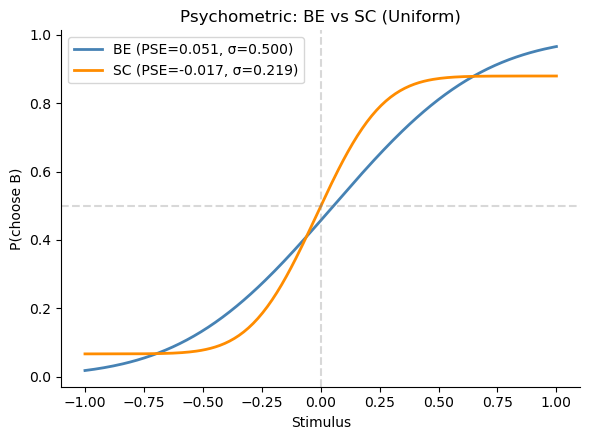

In [4]:
# Fit psychometric to each model's choices
be_fit = fit_psychometric(stimuli, be_choices)
sc_fit = fit_psychometric(stimuli, sc_choices)

x = np.linspace(-1, 1, 200)

fig, ax = plt.subplots(figsize=(6, 4.5))
for fit, col, label in [(be_fit, BE_COL, 'BE'), (sc_fit, SC_COL, 'SC')]:
    if fit.get('success'):
        y = cumulative_gaussian(x, fit['mu'], fit['sigma'],
                                fit['lapse_low'], fit['lapse_high'])
        ax.plot(x, y, color=col, lw=2,
                label=f'{label} (PSE={fit["mu"]:.3f}, σ={fit["sigma"]:.3f})')

ax.axhline(0.5, ls='--', color='grey', alpha=0.3)
ax.axvline(0.0, ls='--', color='grey', alpha=0.3)
ax.set_xlabel('Stimulus')
ax.set_ylabel('P(choose B)')
ax.set_title('Psychometric: BE vs SC (Uniform)')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Update Matrices — The Key Signature

The update matrix (UM) reveals how the previous stimulus influences
the current choice. This is where BE and SC diverge most clearly:

- **BE**: horizontal banding (previous stimulus shifts the boundary)
- **SC**: diagonal/distributed pattern (previous stimulus updates category distributions)


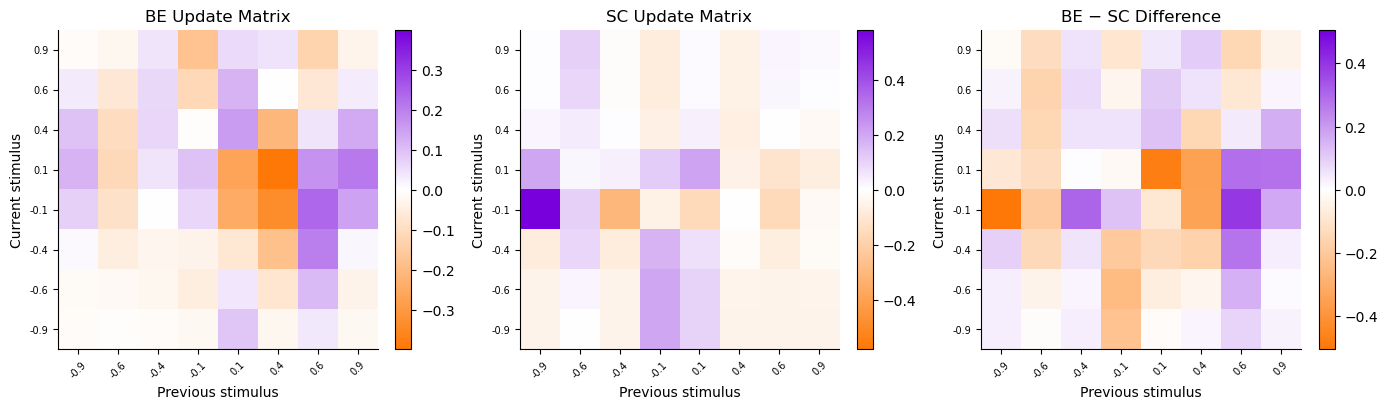

In [6]:
be_um, _, be_info = fit_update_matrix(stimuli, be_choices, categories)
sc_um, _, sc_info = fit_update_matrix(stimuli, sc_choices, categories)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_um(be_um, ax=axes[0], title='BE Update Matrix')
plot_um(sc_um, ax=axes[1], title='SC Update Matrix')
plot_um(be_um - sc_um, ax=axes[2], title='BE − SC Difference')

plt.tight_layout()
plt.show()


## 5. Parameter Exploration: Varying eta_learning (BE)

eta_learning controls how much the boundary shifts toward the previous
stimulus. Higher values = stronger recency effect.


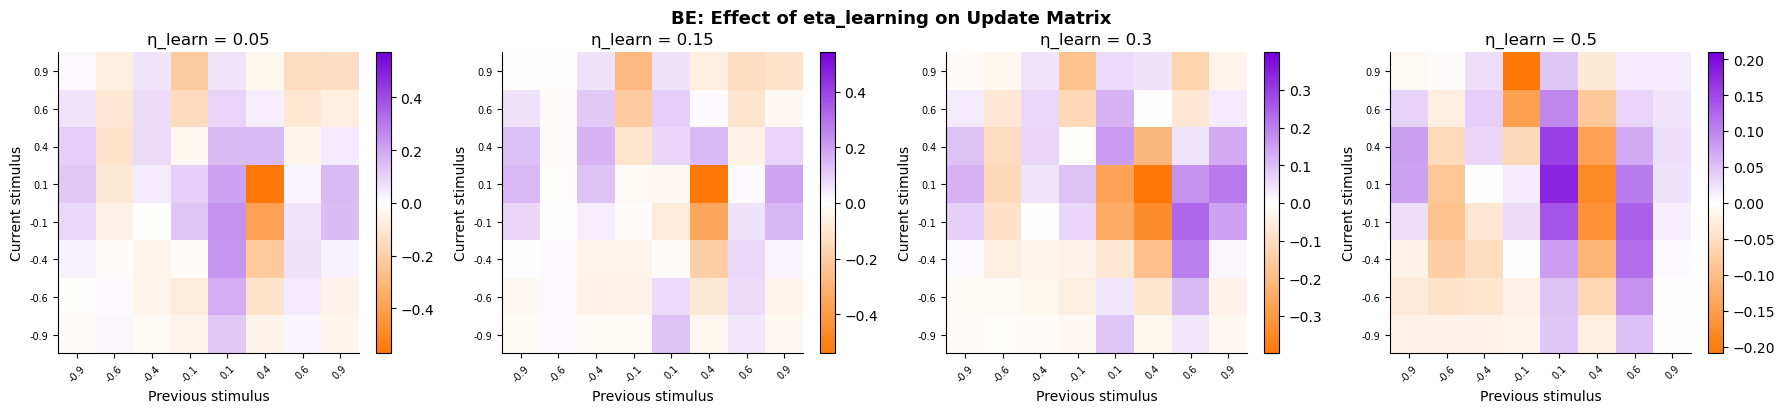

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

eta_values = [0.05, 0.15, 0.30, 0.50]
for ax, eta in zip(axes, eta_values):
    params = BEParams(sigma_percep=0.15, A_repulsion=0.10,
                      eta_learning=eta, eta_relax=0.15)
    ch, _, _, _ = BEModel.simulate_session(
        stimuli=stimuli, categories=categories,
        params=params, initial_state=BEState.initial_uniform(),
        rng=np.random.default_rng(42),
        no_response=no_response, not_blockstart=not_blockstart,
    )
    um, _, _ = fit_update_matrix(stimuli, ch, categories)
    plot_um(um, ax=ax, title=f'η_learn = {eta}')

fig.suptitle('BE: Effect of eta_learning on Update Matrix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Parameter Exploration: Varying gamma (SC)

gamma controls the weight of the categorical prior on distributional
updates. Higher gamma = stronger distributional learning.


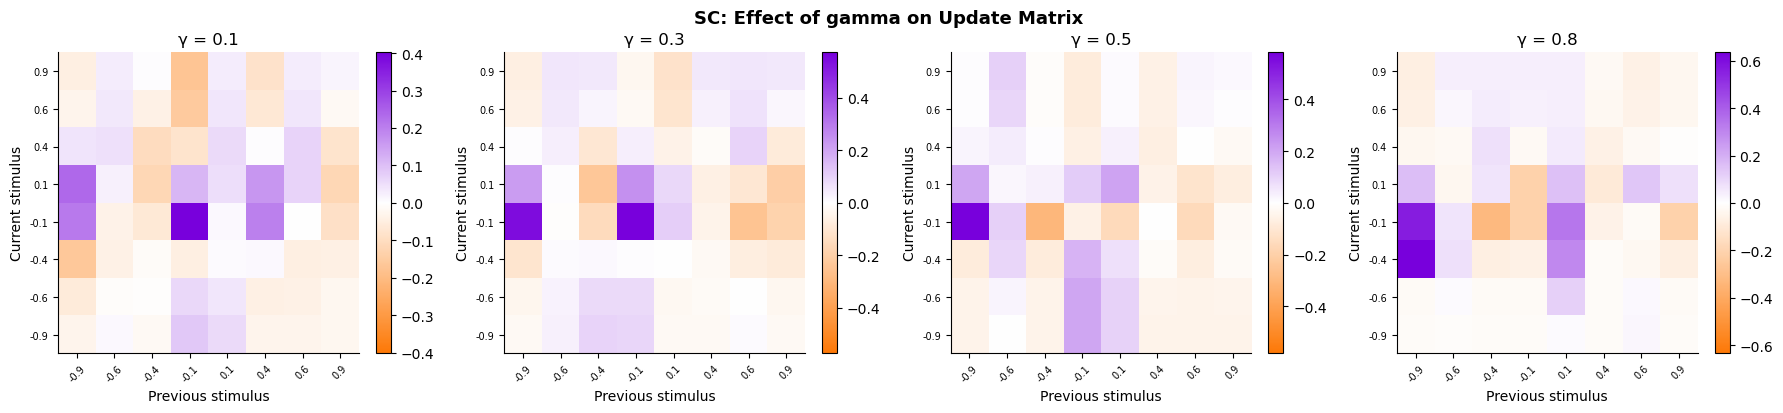

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

gamma_values = [0.1, 0.3, 0.5, 0.8]
for ax, gamma in zip(axes, gamma_values):
    params = SCParams(sigma_percep=0.15, A_repulsion=0.10,
                      gamma=gamma, sigma_update=0.20)
    ch, _, _, _ = SCModel.simulate_session(
        stimuli=stimuli, categories=categories,
        params=params, initial_state=SCState.initial_default(),
        rng=np.random.default_rng(42),
        no_response=no_response, not_blockstart=not_blockstart,
    )
    um, _, _ = fit_update_matrix(stimuli, ch, categories)
    plot_um(um, ax=ax, title=f'γ = {gamma}')

fig.suptitle('SC: Effect of gamma on Update Matrix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Asymmetric Distributions

The real test: with Hard-A or Hard-B asymmetric distributions,
the normative (SC) model predicts a PSE shift toward the
more probable category. BE predicts a boundary shift driven
by recency, which may or may not align with the normative prediction.


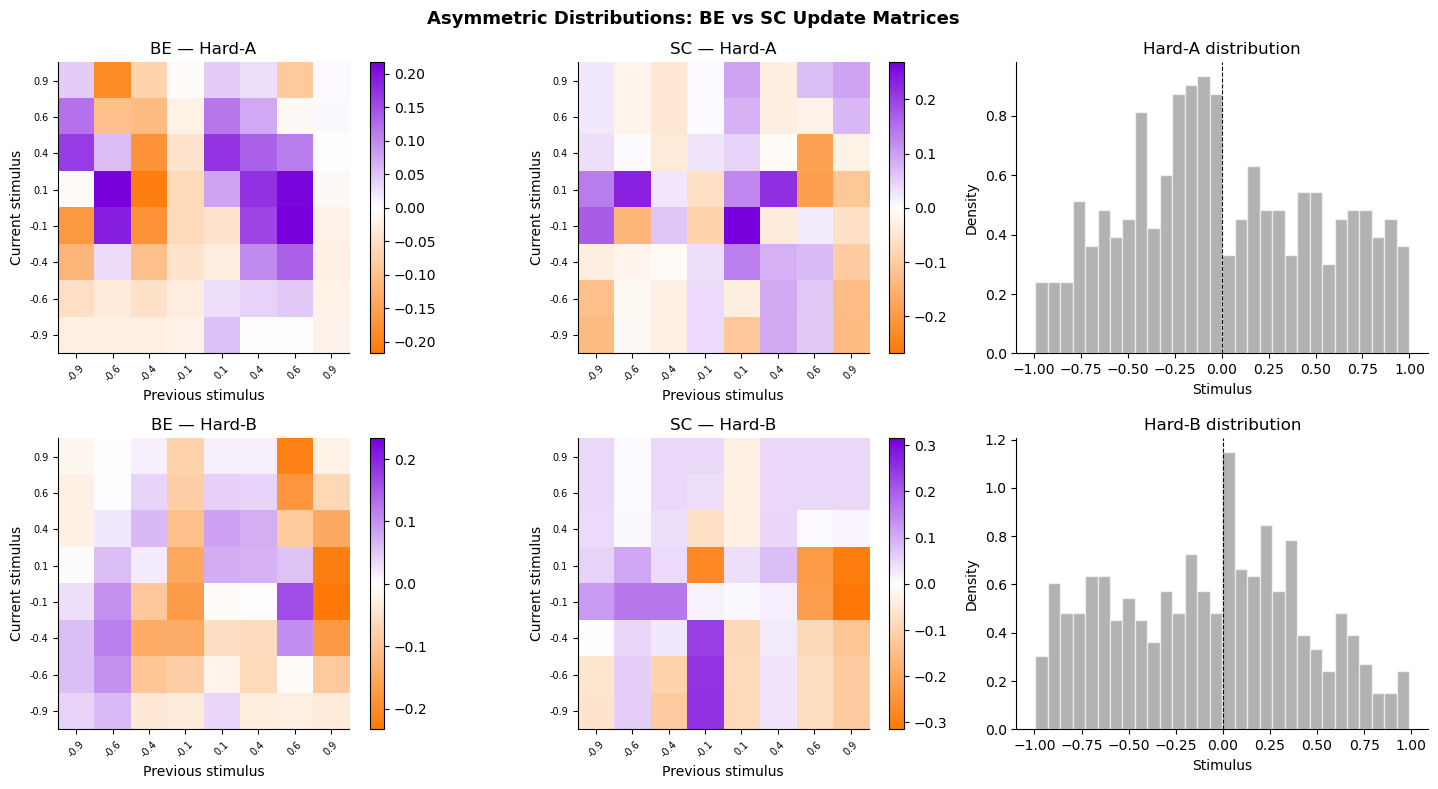

In [11]:
from utils.stimulus_distributions import sample_distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

initial_states = {
    'BE': BEState.initial_uniform(),
    'SC': SCState.initial_default(),
}

for row, (dist_name, dist_label) in enumerate([
    ('hard_a', 'Hard-A'), ('hard_b', 'Hard-B'),
]):
    stim_asym, cat_asym = sample_distribution(
        n_trials, dist_name, rng=np.random.default_rng(row))

    for model_idx, (Model, params, col, mlabel) in enumerate([
        (BEModel, be_params, BE_COL, 'BE'),
        (SCModel, sc_params, SC_COL, 'SC'),
    ]):
        ch, _, _, _ = Model.simulate_session(
            stimuli=stim_asym, categories=cat_asym,
            params=params, initial_state=initial_states[mlabel],
            rng=np.random.default_rng(42),
            no_response=np.zeros(n_trials, dtype=bool),
            not_blockstart=np.concatenate([[False], np.ones(n_trials - 1, dtype=bool)]),
        )
        um, _, _ = fit_update_matrix(stim_asym, ch, cat_asym)
        plot_um(um, ax=axes[row, model_idx],
                title=f'{mlabel} — {dist_label}')

    # Distribution histogram in column 3
    ax_hist = axes[row, 2]
    ax_hist.hist(stim_asym, bins=30, density=True, alpha=0.6,
                 color='grey', edgecolor='white')
    ax_hist.axvline(0, ls='--', color='black', lw=0.8)
    ax_hist.set_title(f'{dist_label} distribution')
    ax_hist.set_xlabel('Stimulus')
    ax_hist.set_ylabel('Density')

fig.suptitle('Asymmetric Distributions: BE vs SC Update Matrices',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

| Feature | BE | SC |
|:--------|:---|:---|
| **Strategy** | Shifts decision boundary toward recent stimuli | Updates internal distributions p(s\|c) |
| **UM signature** | Horizontal banding (boundary shift) | Diagonal/distributed (category learning) |
| **PSE shift (asymmetric)** | Driven by recency, may not be normative | Normative shift toward probable category |
| **Key parameter** | eta_learning (boundary plasticity) | gamma (distributional update weight) |
| **Mapping to circuit** | Discriminative route (sensory → striatum) | Generative route (frontal → auditory) |

The update matrix is the primary diagnostic for distinguishing BE from SC.
Notebooks 10–12 formalise this into a classification pipeline.
